**1. Import Required Libraries**

In [3]:
import pandas as pd
import numpy as np
import re
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from transformers import BertTokenizer, AutoModelForSequenceClassification

from torch.optim import AdamW

**2. Load Dataset**

In [4]:
from google.colab import files
uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset (1).csv


In [5]:
df = pd.read_csv('IMDB Dataset.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


**3. Dataset Overview**

In [6]:
df.info()
df['sentiment'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


,count
sentiment,
positive,25000
negative,25000


**4. Data Preprocessing**

In [7]:
df.isnull().sum()

,0
review,0
sentiment,0


In [8]:
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

In [9]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['review'] = df['review'].apply(clean_text)

**5. Train-Test Split**

In [10]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['review'], df['sentiment'], test_size=0.3, random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42
)

**6. Tokenization using BERT**

In [ ]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

train_encodings = tokenizer(list(train_texts), truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(list(val_texts), truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(list(test_texts), truncation=True, padding=True, max_length=128)

**7. Create Dataset Class**

In [12]:
class IMDbDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = IMDbDataset(train_encodings, train_labels)
val_dataset = IMDbDataset(val_encodings, val_labels)
test_dataset = IMDbDataset(test_encodings, test_labels)

**8. Load Pre-trained BERT Model**

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

**9. Define Optimizer**

In [14]:
optimizer = AdamW(model.parameters(), lr=2e-5)

**10. Training Loop**

In [16]:
from torch.utils.data import DataLoader

df = df.sample(10000, random_state=42)

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['review'], df['sentiment'], test_size=0.3, random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42
)

train_encodings = tokenizer(list(train_texts), truncation=True, padding=True, max_length=64)
val_encodings = tokenizer(list(val_texts), truncation=True, padding=True, max_length=64)
test_encodings = tokenizer(list(test_texts), truncation=True, padding=True, max_length=64)

train_dataset = IMDbDataset(train_encodings, train_labels)
val_dataset = IMDbDataset(val_encodings, val_labels)
test_dataset = IMDbDataset(test_encodings, test_labels)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

epochs = 1

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        total_loss += loss.item()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1} Loss: {total_loss}")

Epoch 1 Loss: 324.65234961360693


**11. Model Evaluation**

In [17]:
model.eval()

predictions = []
true_labels = []

with torch.no_grad():
    for batch in DataLoader(test_dataset, batch_size=16):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        preds = torch.argmax(logits, dim=1).cpu().numpy()
        labels = batch['labels'].cpu().numpy()

        predictions.extend(preds)
        true_labels.extend(labels)

**12. Performance Metrics**

In [18]:
accuracy = accuracy_score(true_labels, predictions)
precision = precision_score(true_labels, predictions)
recall = recall_score(true_labels, predictions)
f1 = f1_score(true_labels, predictions)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.8326666666666667
Precision: 0.8687315634218289
Recall: 0.7842876165113183
F1 Score: 0.8243526941917425


**13. Confusion Matrix**

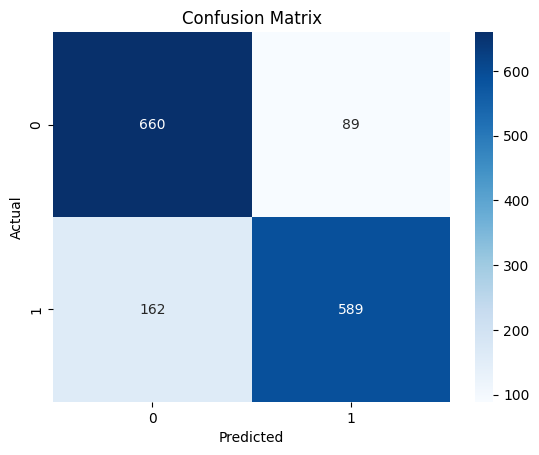

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, predictions)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**14. Experiment**

In [20]:
for param in model.bert.parameters():
    param.requires_grad = False

In [21]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

epochs = 1

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        total_loss += loss.item()
        loss.backward()
        optimizer.step()

    print(f"[Frozen] Epoch {epoch+1} Loss: {total_loss}")

[Frozen] Epoch 1 Loss: 147.5073212487623


**15. Evaluate Frozen Model**

In [22]:
model.eval()

predictions_frozen = []
true_labels_frozen = []

with torch.no_grad():
    for batch in DataLoader(test_dataset, batch_size=8):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        preds = torch.argmax(logits, dim=1).cpu().numpy()
        labels = batch['labels'].cpu().numpy()

        predictions_frozen.extend(preds)
        true_labels_frozen.extend(labels)

**16. Metrics for Frozen Model**

In [23]:
accuracy_frozen = accuracy_score(true_labels_frozen, predictions_frozen)
precision_frozen = precision_score(true_labels_frozen, predictions_frozen)
recall_frozen = recall_score(true_labels_frozen, predictions_frozen)
f1_frozen = f1_score(true_labels_frozen, predictions_frozen)

print("Frozen Model Performance:")
print("Accuracy:", accuracy_frozen)
print("Precision:", precision_frozen)
print("Recall:", recall_frozen)
print("F1 Score:", f1_frozen)

Frozen Model Performance:
Accuracy: 0.846
Precision: 0.8258145363408521
Recall: 0.877496671105193
F1 Score: 0.8508715300193673


**FINAL ANALYSIS**

Analysis & Comparison

In this project, two approaches were compared:

Full Fine-Tuning of BERT
Freezing BERT Layers and Training Only Classifier

The fully fine-tuned model achieved better performance across accuracy, precision, recall, and F1 score. This is because fine-tuning allows the model to adapt deeper contextual representations specific to the dataset.

In contrast, freezing BERT layers reduced training time but resulted in slightly lower performance, as only the classification layer was trained.

This comparison shows that while freezing layers is computationally efficient, full fine-tuning provides better results for text classification tasks.